# Intro

Check the readme files in the folder to learn how to run scans and use defaults vs specify parameters

# Initialize (Run everything in this section before starting experiments)

In [1]:
cfg_file='2026_03_02_smpd_v2_4wm_test.yml'
expt_path = 'C:\\_Data\\SMPD\\2026_0303'

max_t1 = 250 #

## Imports

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

#np.set_printoptions(legacy="1.25")
from qick import QickConfig
from slab_qick_calib.experiments.general.qick_program import QickProgram, QickProgram2Q
from slab_qick_calib.experiments.general.qick_experiment import QickExperiment
from slab_qick_calib.experiments.general.qick_experiment_2q import QickExperiment2Q
from qick.asm_v2 import AveragerProgramV2

from slab_qick_calib.exp_handling.instrumentmanager import InstrumentManager
import slab_qick_calib.experiments as meas
from slab_qick_calib.calib import qubit_tuning, measure_func
from slab_qick_calib.calib.time_tracking import time_tracking
from slab_qick_calib.analysis import qubit_params, fitres
from slab_qick_calib.helpers import qick_check, config, handy
from fridge.bluefors import BlueforsClient
from fridge.credentials import BLUEFORS_HOST, BLUEFORS_PORT, BLUEFORS_API_KEY

from datetime import datetime


%load_ext autoreload
%autoreload 2

# Set color palette and font size
handy.config_figs()
%config InlineBackend.figure_format = 'png'

import matplotlib 
matplotlib.rcParams['path.simplify'] = True
matplotlib.rcParams['path.simplify_threshold'] = 0.1
matplotlib.rcParams['agg.path.chunksize'] = 10000

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
handy.config_figs()


## Set up new config 
Set to variables to True when setting up a new experiment config file. 

Note: make sure you set your ADC/DAC channels correctly. This code does not automatically fill in the ADC/DAC into your configuration file, so you should check yourself to make sure these values are correct. 

There are several elements that you may want to customize based on your readout parameters and coherence times. Check readme file config_manual.md

In [120]:
# Set to false if you aren't creating a new one (so set to false as soon as you run it)
new_config = False
new_folder = False

nqubits = 2 # For SMPD, we have 1 qubit per chip, but it's coupled to 2 resonators, so we can treat it as a 2 qubit system for the purposes of the config file.
rfsoc_alias = 'smpd_qick'
t1_guess = 50 
ip = '192.168.137.93' # ip address of name server that rfsoc is connected to 
import os

configs_dir = os.path.join(os.getcwd(),'../', 'configs')

cfg_file_path = os.path.join(configs_dir, cfg_file)
images_dir = os.path.join(expt_path, 'images')
data_dir = os.path.join(expt_path, 'data')
summary_dir = os.path.join(images_dir, 'summary')

if new_config or new_folder:
    if new_config:
        config.init_config(cfg_file_path, nqubits, type='full', aliases=rfsoc_alias, t1=t1_guess, ip=ip)
        config.init_model_config(cfg_file_path, nqubits)

    if not os.path.exists(expt_path):
        os.makedirs(expt_path)
        os.mkdir(images_dir)
        os.mkdir(summary_dir)
        os.mkdir(data_dir)

print('Data will be stored in', expt_path)

Data will be stored in C:\_Data\SMPD\2026_0303


## Connect to RFSoC
Before running first cell, make sure a nameserver is running on the network, the Qick board is connected to it, and the ip address listed below matches that of the nameserver. 

You just need to run the first cell, then should be able to run any other cell in whatever order. 

If you need to restart the RFSoC, you should reconnect it to the nameserver and rerun this. 

In [121]:
# Results config file
cfg_path = os.path.join(os.getcwd(),'..', 'configs', cfg_file)
auto_cfg = config.load(cfg_path)

# Connect to instruments
im = InstrumentManager(ns_address=auto_cfg['aliases']['ip'], port=9090)
print(im)
soc = QickConfig(im[auto_cfg['aliases']['soc']].get_cfg())
#print(soc)

cfg_dict = {'soc': soc, 'expt_path': expt_path, 'cfg_file': cfg_path, 'im': im}

                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


{'Pyro.NameServer': <Pyro4.core.Proxy at 0x188ee8a7f70; not connected; for PYRO:Pyro.NameServer@192.168.137.1:9090>, 'smpd_qick': <Pyro4.core.Proxy at 0x188ef1c5210; not connected; for PYRO:obj_0605df7cfe084b8cb92aa48c63350e40@192.168.137.233:44261>, 'Qick233': <Pyro4.core.Proxy at 0x188eee7fa00; not connected; for PYRO:obj_d0f8a0ce1e0e43f1afb22e3d5f5731b5@192.168.137.233:44525>}


In [5]:
bf = BlueforsClient(
    host=BLUEFORS_HOST,
    port=BLUEFORS_PORT,
    api_key=BLUEFORS_API_KEY,
    verify_ssl=False,
)
print(f"MXC: {bf.get_mxc_temperature()*1000:.2f} mK")

MXC: 10.08 mK


# Applets (Not ncessary, run if needed)

## How to update config (you can also just edit yml directly)

In [ ]:
# #                                          param   value qubit #
# auto_cfg = config.update_readout(cfg_path, 'lamb', 5, qi)
# auto_cfg = config.update_qubit(cfg_path, 'f_ge', 5700, qi)

# # For multiple levels of nesting: 
# auto_cfg = config.update_qubit(cfg_path, ('pulses','pi_ge','gain'), 0.2, qi)

## Print scan params

In [ ]:
t1 = meas.T1Experiment(cfg_dict, qi=0, print=True)

In general, all scans will be interacted with either by running default, or giving arguments from params dict. 
You can run scans on list of different qubits or just one by adding first couple lines of each cell. 
Flag of update is used to decide if to set new config vals based on output of scan (if the fit looks good)

## Check QICK issues

### Check mirror frequencies on qubit

In [ ]:
qick_check.check_freqs(0, cfg_dict)

### Check mirror frequencies from resonators

In [ ]:
qick_check.check_resonances(cfg_dict)

### Check sampling rates and minimum point spacing

In [ ]:

fnyq = cfg_dict['soc']._get_ch_cfg(ro_ch=0)['f_dds']/2
clock_tick = 1e3*cfg_dict['soc'].cycles2us(1)
print(f'ADC Nyquist frequency is {fnyq} MHz')
print(f'1 clock tick is {clock_tick} ns')

### Make sure you're not near the nyquist frequency of the ADC

In [ ]:
qick_check.check_adc(cfg_dict)

# Time of Flight (TOF)

TOF measures the time it takes for the signal to run through the wires. It will give us the time in clock ticks that we should wait to make a measurements 

 Use this to set trig_offset in config file

  0%|          | 0/1 [00:00<?, ?it/s]

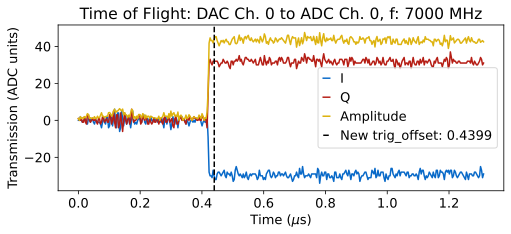

In [136]:
qubit_list = np.arange(3)
qubit_list = [0]
for qi in qubit_list:  
        tof=meas.ToFCalibrationExperiment(cfg_dict=cfg_dict, qi=qi, params={'frequency':7000,'rounds':1, 'gain': 0.1})

        # Set frequency of choice and readou
        # t length (up to 13 us for standard ZCU216 firmware, readout)
        #tof=meas.ToFCalibrationExperiment(cfg_dict=cfg_dict, qi=qi,params={'readout_length':13})#,)
        

# 4WM Loopback setup

Work in progress, do not delete.

In [ ]:
from slab_qick_calib.exp_handling.datamanagement import AttrDict

class SMPD4WMLoopbackProgram(QickProgram2Q):
    """
    A program that sends a readout pulse and captures the response to measure time of flight.

    This class extends QickProgram to implement the specific pulse sequence needed for
    time of flight calibration. It can optionally apply a pi pulse to excite the qubit
    to the |1⟩ state before measurement.
    """

    def __init__(self, soccfg, final_delay, cfg):
        """
        Initialize the LoopbackProgram.

        Args:
            soccfg: SoC configuration
            final_delay: Final delay time after the pulse sequence
            cfg: Configuration dictionary containing experiment parameters
        """
        super().__init__(soccfg, final_delay, cfg)

    def _initialize(self, cfg):
        """
        Initialize program parameters from configuration.

        Sets up the frequency, gain, readout length, and phase parameters from the
        experiment configuration. Optionally creates a pi pulse if checking the excited state.

        Args:
            cfg: Configuration dictionary
        """
        cfg = AttrDict(self.cfg)
        # self.frequency = cfg.expt.frequency
        # self.gain = cfg.expt.gain
        # self.readout_length = cfg.expt.readout_length
        # self.phase = cfg.expt.phase
        super()._initialize(cfg, readout="standard")

        # Create a π pulse to excite the qubit from |0⟩ to |1⟩
        #if cfg.expt.check_e:
        #    super().make_cfg_pulse(cfg.expt.qubit[0], cfg.device.qubit.f_ge, "pi_ge")

        # envelope for readout pulses and pump pulses
        self.add_gauss(
            ch = cfg.hw.soc.dacs.readout.ch[0], 
            name = 'gauss_buffer',
            sigma = cfg.expt.sigma,
            length = 6*cfg.expt.sigma,
            maxv = cfg.expt.gain_b,
            even_length = True)
        
        self.add_pulse(
            ch = cfg.hw.soc.dacs.readout.ch[0],
            name = 'pulse_buffer',
            ro_ch = cfg.hw.soc.adcs.readout.ch[0],
            style = 'flat_top',
            freq = cfg.expt.f_b,
            phase = cfg.device.readout.phase[0],
            gain = cfg.expt.gain_b,
            length = cfg.expt.t_b,
            envelope = 'gauss_buffer',
        )

        self.add_gauss(
            ch = cfg.hw.soc.dacs.readout.ch[1], 
            name = 'gauss_waste',
            sigma = cfg.expt.sigma,
            length = 6*cfg.expt.sigma,
            maxv = cfg.expt.gain_w,
            even_length = True)
        
        self.add_pulse(
            ch = cfg.hw.soc.dacs.readout.ch[1],
            name = 'pulse_waste',
            ro_ch = cfg.hw.soc.adcs.readout.ch[1],
            style = 'flat_top',
            freq = cfg.expt.f_w,
            phase = cfg.device.readout.phase[1],
            gain = cfg.expt.gain_w,
            length = cfg.expt.t_m,
            envelope = 'gauss_waste',
        )

        self.add_gauss(
            ch = cfg.hw.soc.dacs.qubit.ch[0], 
            name = 'gauss_pump',
            sigma = cfg.expt.sigma,
            length = 6*cfg.expt.sigma,
            maxv = cfg.expt.gain_p,
            even_length = True)
        
        self.add_pulse(
            ch = cfg.hw.soc.dacs.qubit.ch[0],
            name = 'pulse_pump',
            #ro_ch = cfg.hw.soc.adcs.readout.ch[1],
            style = 'flat_top',
            freq = cfg.expt.f_p,
            phase = 0,
            gain = cfg.expt.gain_p,
            length = cfg.expt.t_p,
            envelope = 'gauss_pump',
        )

        



    def _body(self, cfg):
        """
        Define the main body of the pulse sequence.

        This method implements the actual pulse sequence:
        1. Configure readout
        2. Optionally apply a pi pulse if checking excited state
        3. Apply a readout pulse
        4. Trigger data acquisition

        Args:
            cfg: Configuration dictionary
        """
        cfg = AttrDict(cfg)
        # if self.type=='full':
        # if self.adc_type == "dyn":
        #     self.send_readoutconfig(ch=cfg.hw.soc.adcs.readout.ch[0], name="readout", t=0)
        #self.pulse(ch=self.res_ch, name="readout_pulse", t=0.5)

        # for q in range(len(cfg.expt.qubit)):
        #     self.send_readoutconfig(ch=self.adc_ch[q], name=f"readout_{q}", t=0)
        self.pulse(ch=cfg.hw.soc.dacs.readout.ch[1], name="pulse_waste", t=0)            
        self.pulse(ch=cfg.hw.soc.dacs.readout.ch[0], name="pulse_buffer", t=0.5)
        self.pulse(ch=cfg.hw.soc.dacs.qubit.ch[0], name="pulse_pump", t=0.2)
        
        self.trigger(
            ros=cfg.hw.soc.adcs.readout.ch,
            pins=[0,1],
            t=cfg.device.readout.trig_offset[0]
            )

        # self.trigger(
        #     ros=[cfg.hw.soc.adcs.readout.ch[1]],
        #     pins=[1],
        #     t=cfg.device.readout.trig_offset[1],
        # )
        

# ====================================================== #


class SMPD4WMLoopbackExperiment(QickExperiment2Q):
    """
    Time of Flight Calibration Experiment

    This class implements the experiment to calibrate the time of flight between
    sending a readout pulse and receiving the response. It measures the delay
    that should be applied to the ADC trigger to capture the signal at the right time.

    Experimental Config Parameters:
        rounds: Number of software averages for the measurement
        readout_length [us]: Length of the readout pulse
        trig_offset [us]: Current trigger offset for the ADC
        gain [DAC units]: Amplitude of the readout pulse
        frequency [MHz]: Frequency of the readout pulse
        reps: Number of averages per point
        qubit: List containing the qubit index to calibrate
        phase: Phase of the readout pulse
        final_delay [us]: Final delay after the pulse sequence
        check_e: Whether to excite qubit to |1⟩ state before measurement
        use_readout: Whether to use existing readout parameters (gain and phase)
    """

    def __init__(
        self,
        cfg_dict={},
        progress=None,
        prefix=None,
        qi=[0,1],
        params={},
        go=True,
        print=False,
    ):
        """
        Initialize the ToF calibration experiment.

        Args:
            cfg_dict: Configuration dictionary
            progress: Progress tracking object
            prefix: Prefix for experiment name (default: "adc_trig_offset_calibration_qubit{qi}")
            qi: Qubit index
            params: Additional parameters to override defaults
            go: Whether to run the experiment immediately after initialization
        """
        if prefix is None:
            prefix = "4wm_loopback"
            for q in qi:
                prefix += f"_Q{q}"

        super().__init__(cfg_dict=cfg_dict, qi=qi, prefix=prefix, progress=progress)

        # Define default parameters for the experiment
        params_def = {
            "rounds": 1000,  # Number of software averages
            "readout_length": 1,  # Readout pulse length [us]
            "trig_offset": self.cfg.device.readout.trig_offset,  # Current trigger offset [us]
            "gain": self.cfg.device.readout.max_gain,  # Readout pulse amplitude
            "frequency": self.cfg.device.readout.frequency,  # Readout frequency [MHz]
            "reps": 1,  # Number of averages per point
            "qubit": qi,  # Qubit index to calibrate
            "phase": 0,  # Phase of the readout pulse
            "final_delay": 0.1,  # Final delay after sequence
            "check_e": False,  # Whether to excite qubit before measurement
            "use_readout": False,  # Whether to use existing readout parameters
            ## new parameters for 4wm loopback
            "sigma": 0.02, # sigma of the gaussian envelope
            "t_m": self.cfg.device.readout.readout_length[1], # length of the waste pulse [us]
            "gain_w": self.cfg.device.readout.gain[1], # gain of the waste pulse
            "f_w": self.cfg.device.readout.frequency[1], # frequency of the waste pulse
            "t_b": 1, # length of the buffer pulse [us]
            "gain_b": self.cfg.device.readout.gain[0], # gain of the buffer pulse
            "f_b": self.cfg.device.readout.frequency[0], # frequency of the buffer pulse
            "t_p": 1, # length of the pump pulse [us]
            "gain_p": 0.1, # gain of the pump pulse
            "f_p": 5500, # frequency of the pump pulse

        }

        # If use_readout is True, use the existing readout gain and phase
        if "use_readout" in params and params["use_readout"]:
            params_def["gain"] = self.cfg.device.readout.gain[qi]
            params_def["phase"] = self.cfg.device.readout.phase[qi]

        # Merge default parameters with provided parameters
        self.cfg.expt = {**params_def, **params}
        if print:
            super().print()
            go = False
        # Run the experiment if go is True
        if go:
            self.go(analyze=False, display=False, progress=True, save=True)
            self.analyze(fit=self.cfg.expt.use_readout)
            self.display(adc_trig_offset=self.cfg.expt.trig_offset)
            # self.display(adc_trig_offset=self.cfg.expt.trig_offset)

    def acquire(self, progress=False):
        """
        Acquire data for the ToF calibration.

        This method runs the LoopbackProgram to send a readout pulse and capture
        the response. It calculates the amplitude and phase of the response signal.

        Args:
            progress: Whether to show progress during acquisition

        Returns:
            Dictionary containing the acquired data (time axis, I/Q values, amplitude, phase)
        """

        # super().acquire(SMPD4WMLoopbackProgram)
        final_delay = 10

        # Create and run the LoopbackProgram
        prog = SMPD4WMLoopbackProgram(
            soccfg=self.soccfg,
            final_delay=final_delay,
            cfg=self.cfg,
        )


        # Initialize data storage lists
        xpts, amps, phases, avgi, avgq = [], [], [], [], []

        # Record start time
        now = datetime.now()
        current_time = now.strftime("%Y-%m-%d %H:%M:%S")
        current_time = current_time.encode("ascii", "replace")

        # Acquire decimated I/Q data
        iq_list = prog.acquire_decimated(
            self.im[self.cfg.aliases.soc],
            rounds=self.cfg.expt.rounds,
            progress=progress,
        )

        # Extract time axis and I/Q values
        
        xpts = prog.get_time_axis(ro_index=0)
        # print(iq_list)
        # Process I/Q data for each qubit
        for i in range(len(iq_list)):
            amps.append(np.abs(iq_list[i].dot([1, 1j])))
            phases.append(np.angle(iq_list[i].dot([1, 1j])))
            avgi.append(iq_list[i][:, 0])
            avgq.append(iq_list[i][:, 1])

        # Compile data dictionary
        data = {
            "xpts": xpts,
            "avgi": avgi,
            "avgq": avgq,
            "amps": amps,
            "phases": phases,
            "start_time": current_time,
        }
        

        # Convert all data to numpy arrays
        # for key in data:
        #     data[key] = np.array(data[key])
            
        self.data = data
        return data

    def analyze(self, data=None, fit=False, findpeaks=False, **kwargs):
        """
        Analyze the acquired data.

        When fit=True, performs a two-pass exponential fit to the amplitude data
        to extract the resonator ring-up time constant.

        Args:
            data: Data to analyze (default: self.data)
            fit: Whether to fit exponential to amplitude (resonator ring up)
            findpeaks: Whether to find peaks in the data
            **kwargs: Additional keyword arguments

        Returns:
            The data dictionary (with 'ring_up_fit' key added when fit=True)
        """
        if data is None:
            data = self.data

        if not fit:
            # Compute trig_offset: find half-max crossing point + 10 ns
            data['trig_offset'] = []
            for i in range(len(data['amps'])):
                half_max = np.max(data['amps'][i]) / 2
                crossing_idx = np.argmin(np.abs(data['amps'][i] - half_max))
                data['trig_offset'].append(data['xpts'][crossing_idx] + 0.02)  # +20 ns in µs

        if fit:
            qi = self.cfg.expt.qubit[0]
            kappa = self.cfg.device.readout.kappa[qi]
            xdata = data['xpts']
            t_min = self.cfg.device.readout.trig_offset[qi] + 0.06
            max_time = t_min + 2 / kappa
            mask = (xdata > t_min) & (xdata < max_time)
            xdata = xdata - t_min
            amps_masked = data['amps'][mask]

            # Initial guesses: c=steady state, a=start-end (negative for ring-up), b~kappa
            c0 = np.mean(amps_masked[-20:-1])
            a0 = amps_masked[0] - c0
            b0 = kappa * 3
            p0 = [a0, b0, c0]

            popt, pcov = curve_fit(exp_func, xdata[mask], amps_masked, p0=p0)
            self.data['t_min'] = t_min
            self.data['ring_up_fit'] = {'popt': popt, 'pcov': pcov, 'mask': mask}
            self.data['ring_up_amplitude'] = popt[0]
            self.data['ring_up_rate'] = popt[1]
            self.data['ring_up_offset'] = popt[2]

        return data

    def display(self, data=None, adc_trig_offset=0, save_fig=True, **kwargs):
        """
        Display the results of the ToF calibration.

        This method plots the I and Q values against time and marks the current
        trigger offset with a vertical line. If ring-up fit data is available,
        an additional plot shows the exponential fit.

        Args:
            data: Data to display (default: self.data)
            adc_trig_offset: Current ADC trigger offset to mark on the plot
            save_fig: Whether to save the figure
            **kwargs: Additional keyword arguments
        """
        if data is None:
            data = self.data

        for q_ind in self.cfg.expt.qubit:
            # Get qubit index, ADC channel, and DAC channel
            adc_ch = self.cfg.hw.soc.adcs.readout.ch[q_ind]
            dac_ch = self.cfg.hw.soc.dacs.readout.ch[q_ind]

            # Create figure and plot I/Q data
            fig, ax = plt.subplots(1, 1, figsize=(8, 3))
            ax.set_title(
                f"Time of Flight: DAC Ch. {dac_ch} to ADC Ch. {adc_ch}, f: {self.cfg.device.readout.frequency[q_ind]} MHz"
            )
            ax.set_xlabel("Time ($\mu$s)")
            ax.set_xlabel('sample index')
            ax.set_ylabel("Transmission (ADC units)")

            plt.plot(data["xpts"], data["avgi"][q_ind], label="I")
            plt.plot(data["xpts"], data["avgq"][q_ind], label="Q")
            plt.plot(data["xpts"], data["amps"][q_ind], label="Amplitude")
            #plt.axvline(adc_trig_offset, c="k", ls="--", label=f"Old trig_offset: {adc_trig_offset:.4f}")
            # if 'trig_offset' in data:
            #     plt.axvline(data['trig_offset'][q_ind], c="k", ls="--", label=f"New trig_offset: {data['trig_offset'][q_ind]:.4f}")
            plt.legend()
            plt.show()

            # Save figure if requested
            if save_fig:
                super().save_fig(fig)

        # Display ring-up fit if available
        if 'ring_up_fit' in self.data:
            popt = self.data['ring_up_fit']['popt']
            mask = self.data['ring_up_fit']['mask']
            t_min = self.data['t_min']
            rate = self.data['ring_up_rate']
            xfit = self.data['xpts'][mask] - t_min
            yfit = self.data['amps'][mask]

            kappa = self.cfg.device.readout.kappa[q_ind]
            fit_label = f'Fit ($\\kappa_{{fit}}$ = {rate/2/np.pi:.2f} MHz, $\\kappa_{{fit}}/\\kappa/$ = {rate / kappa/np.pi/2:.2f})'

            fig_ring, ax_ring = plt.subplots(1, 1, figsize=(8, 3))
            ax_ring.plot(xfit, yfit, 'o', label='Data')
            ax_ring.plot(xfit, exp_func(xfit, *popt), '-', label=fit_label)
            ax_ring.set_xlabel('Time ($\\mu$s)')
            ax_ring.set_ylabel('Amplitude')
            ax_ring.legend()
            ax_ring.set_title(f'Resonator ring up for Q{q_ind}')
            plt.show()

            if save_fig:
                super().save_fig(fig_ring, suffix="_ringup_fit")


    def update(self, verbose=True):
        qi = self.cfg.expt.qubit[0]
        cfg_file = self.config_file
        if 'trig_offset' in self.data:
            config.update_readout(cfg_file, 'trig_offset', self.data['trig_offset'], qi, verbose=verbose)



notes 20260303 (CZ)

1. set gauss length to 6*sigma. that's counting both sides. so the entire length of the envelope is 6*sigma after truncating.
2. Struggling about defining pulses on different dacs.. not sure how does it work. maybe find an example tomorrow.

notes OW
1. used 2Q versions of Programs and Experiments. lots of muddling around to get variables right and whatever
2. it seems that the outputs are different amounts of time -- the buffer is always 2x the number of samples in the waste. not sure why

  0%|          | 0/1000 [00:00<?, ?it/s]

Saving C:\_Data\SMPD\2026_0303\data\4wm_loopback_Q0_Q1_00081.h5


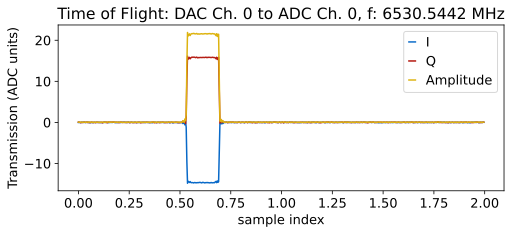

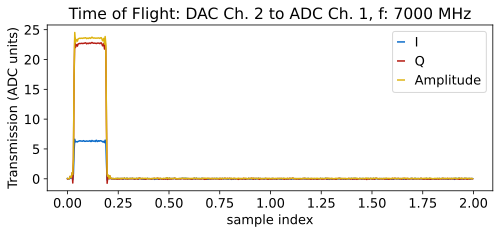

In [164]:
smpd4wmexpt = SMPD4WMLoopbackExperiment(cfg_dict=cfg_dict, qi=[0,1], params={'rounds':1000, 'f_w':7000,'gain_w':0.1,'t_m':0.16, 'gain_b': 0.1, 't_b': 0.16, 'f_b':7000, 'gain_p': 1, 't_p': 1.5, 'sigma': 0.01})

# Resonator Spectroscopy 

Run resonator spectroscopy for all resonators by choosing a large frequency scan to look over. The scan will then find the different resonators and fill in the config file with their respective frequencies. In the autocalibration, there will be a finer sweep of each resonator to more accurately find its frequency. The frequencies are saved in <code>auto_cfg.device.readout.frequency</code>

## Coarse 

This will perform peak finding
Use params to specify frequency range, averaging, gain, expts. 
If gain is too high, you may be in punch out region, where resonators disappear, or above it 

In [ ]:
qi=1 # We only run this once for all qubits on a single feedline, this is a dummy value to make the scan work 
params={'start':4000, 'span':4000, 'reps':500, 'gain': 1, 'expts':1000}
rspecc = meas.ResSpec(cfg_dict, qi=qi, style='coarse', progress=True, params=params)
res_values = rspecc.data['coarse_peaks']

In [ ]:
qi=1 # We only run this once for all qubits on a single feedline, this is a dummy value to make the scan work 
gain_list = [0.005, 0.01, 0.03, 0.1, 0.3, 1]
rep_list = [8000, 4000, 1500, 500, 100, 50]

# Store phases from each scan
all_phases = []
frequencies = None

for gain, reps in zip(gain_list, rep_list):
    params={'start':6750, 'span':1500, 'reps':reps, 'gain': gain, 'expts':200}
    rspecc = meas.ResSpec(cfg_dict, qi=qi, style='coarse', progress=True, params=params)
    res_values = rspecc.data['coarse_peaks']
    
    # Store phases and frequency axis
    all_phases.append(rspecc.data['phase_fix'])
    if frequencies is None:
        frequencies = rspecc.data['freq'] 


In [ ]:

plt.figure(figsize=(10, 6))
for i, (gain, phases) in enumerate(zip(gain_list, all_phases)):
    plt.plot(frequencies[1:-1], phases, label=f'gain={gain}', alpha=0.7)

plt.xlabel('Frequency (MHz)')
plt.ylabel('Phase')
plt.legend()

Change prom (prominence value) to adjust how many peaks you find

In [ ]:
len(np.polyval(polyfit, rspec.data['freq']))

In [ ]:
unwrapped = np.unwrap(rspecc.data['phases'])
polyfit = np.polyfit(rspecc.data['freq'][:200], unwrapped[:200], 1)
unwrapped -= np.polyval(polyfit, rspecc.data['freq'])

plt.plot(rspecc.data['freq'],unwrapped)

plt.figure()
IQ = rspecc.data['amps'] * np.exp(1j * unwrapped)
plt.plot(IQ.real, IQ.imag, 'o-')

In [ ]:
rspecc.analyze(peaks=True, debug=True, fit=False, prom=0.025)
rspecc.display(peaks=True, fit=False)
res_values = rspecc.data['coarse_peaks']

Can delete values from res_values if they don't seem to be real res_values. 

In [ ]:
print(res_values)
#res_values = np.delete(res_values, 0)

## Fine

This will fit the resonance amplitude

Can run scan with default options, or specify your own, by commenting out different lines and editing paramters. 

### First time after running coarse scan, using res_values list
Assumes you have the same number of res_values as qubits. 
First time you run scan, plot will appear weird first because it plots the resonator frequency in the config on the same plot. Just run again

In [ ]:
### we should not need to use this unless we move on to test more than one resonator on a single chain.
'''
update=False
num_peaks = len(res_values)

for qi in range(1,len(res_values)):    
    # Used for initial finding of resonance 
    rspec = meas.ResSpec(cfg_dict, qi=qi, params={'span':5, 'center':res_values[qi]}, disp_kwargs={'plot_res':False})

    if update: rspec.update()
'''

### Fine resonator scan

Once the correct frequencies are saved to your config file. 

In [ ]:
auto_cfg = config.load(cfg_path)
update=False # Set to true if you want to update the config file with the new resonance values

# comment out one of these 
# qubit_list = np.arange(6)
qi = 0
ifauto = False

if ifauto:
    # Fully automated, using previous fit to kappa to set span
    rspec = meas.ResSpec(cfg_dict, qi=qi, params={'span':'kappa'})
    gain = auto_cfg.device.readout.gain[qi]
else:
    # Manually set the span and gain 
    gain = 0.01
    #rspec = meas.ResSpec(cfg_dict, qi=qi, params={'span':6, 'gain':gain, 'reps':1000, 'expts':200,'length':6})
    rspec = meas.ResSpec(cfg_dict, qi=qi, params={'span':5, 'gain':gain, 'reps':1000, 'expts':1000})

if update: rspec.update()

In [ ]:
unwrapped = np.unwrap(rspec.data['phases'])
polyfit = np.polyfit(rspec.data['freq'][:20], unwrapped[:20], 1)
unwrapped -= np.polyval(polyfit, rspec.data['freq'])
plt.plot(unwrapped)

In [ ]:
plt.plot(np.unwrap(rspec.data['phase_fix']))

unwrapped = np.unwrap(rspec.data['phase_fix'])
polyfit = np.polyfit(rspec.data['freq'][:20], unwrapped[:20], 1)
unwrapped -= np.polyval(polyfit, rspec.data['freq'][1:-1])

plt.plot(unwrapped)

In [ ]:
import importlib
importlib.reload(fitres)

In [ ]:
### Fit resonator with circle fit to extract fr, Q, Qc, and other parameters. This is a more robust method than fitting the amplitude and phase separately, as it accounts for the fact that the resonance circle in the IQ plane can be distorted by various factors.
unwrapped = np.unwrap(rspec.data['phase_fix'])
polyfit = np.polyfit(rspec.data['freq'][:20], unwrapped[:20], 1)
unwrapped -= np.polyval(polyfit, rspec.data['freq'][1:-1])

amps = rspec.data['amps'][1:-1]
phases = unwrapped
freqs = rspec.data['freq'][1:-1]
S21 = amps * np.exp(1j * phases)
start_idx = 0
end_idx = -1
plt.figure() 
plt.plot(S21.real[:], S21.imag[:])
plt.axis('equal')
#p0 = [phi_1, tau_1, Imtau_1]
p0 = [0, 0, 0]
fr, Qr, Qc, a, phi, tau, Qc, _ = fitres.finefit(freqs,S21,6917.22,p0=p0)
fit_plot = fitres.resfunc3(freqs[:], fr, Qr, Qc, a, phi, tau)
plt.plot(fit_plot.real, fit_plot.imag, 'r-',label='$f_r$={:.4f} MHz\n $\kappa$={:.4f} MHz\n$\kappa_c$={:.4f} MHz'.format(fr,fr/Qr, fr/(2*Qc)))
plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.title(f'qi{qi} resonator, gain={gain}')
plt.legend()

plt.savefig(os.path.join(summary_dir, f'res_fit_qi{qi}_gain{gain}.png'), dpi=250)


### Low gain (for purcell)

In [ ]:
update=True # Set to true if you want to update the config file with the new resonance values

# comment out one of these 
qubit_list = np.arange(6)
#qubit_list=[0,1,2]

for qi in qubit_list:    
    # Manually set the span and gain 
    #rspec = meas.ResSpec(cfg_dict, qi=qi, params={'span':1, 'gain':0.3})

    # Fully automated, using previous fit to kappa to set span
    rspec = meas.ResSpec(cfg_dict, qi=qi, params={'span':'kappa', 'gain':0.1, 'reps':1200})
    auto_cfg = config.update_config(cfg_path[0:-4]+'_model.yml' , None,'kappa_low', float(rspec.data['kappa']), qi)

## Resonator Power Spectroscopy 

Find a good value for gain to park your readout at until you run readout optimization. From the 2D sweep that is produced, choose a value for gain that is right before the resonator punches out. Want to choose a high value for gain because we want to be in the shot noise limited regime which increases our signal:noise ratio. 

In [ ]:
update=False

qubit_list = np.arange(6)
# f_off: center scan at res_freq - f_off
qubit_list=[1]
d=[]
for qi in qubit_list:
    #params={'rng':200,'max_gain':1, 'span':10,"f_off":3,'expts_gain':25,'expts':100,'reps':0.5} #buffer
    params={'rng':3,'max_gain':0.03, 'span':40,"f_off":12,'expts_gain':75,'expts':100,'reps':5} #waste
    #params={'rng':10,'max_gain':0.07, 'span':4,'expts_gain':30,'f_off':0.5,'expts':100,'reps':70} #waste
    rpowspec=meas.ResSpecPower(cfg_dict, qi=qi, params=params, live_plot=False, disp_kwargs={'plot_phase':True})
    # rpowspec.analyze(lowgain=0.035)
    d.append(rpowspec)
    if update:
        auto_cfg = config.update_readout(cfg_path, 'lamb', rpowspec.data['lamb_shift'], qi)

### Example of plotting 2D scans for a bunch of qubits together
Can also use for varying a parameter on one qubit and plotting the results together

In [ ]:
auto_cfg = config.load(cfg_path)
horz_line = auto_cfg.device.readout.gain
handy.plot_many(d, title='Resonator Power', save_path=cfg_dict['expt_path'], chan='amps', yax='log', norm=True, horz_line=horz_line)

### Save gain values 

In [ ]:
# assign the resonator gain to the results config file
gain_values = [0.1,0.01]
for i, qi in enumerate(qubit_list):
    auto_cfg = config.update_readout(cfg_file, 'gain', gain_values[i], qi)

# Qubit Spectroscopy

## Find qubits
More automated, zooms out and adds power if no peak visible. Best to use if you're feeling confident, otherwise use more manual stuff in next cell. 

In [ ]:
qubit_list = np.arange(6)
qubit_list= [0]

bad_qubits=[]
for qi in qubit_list:
    status, ntries = qubit_tuning.find_spec(qi, cfg_dict, start='medium')
    if not status:
        bad_qubits.append(qi)

## General search, specify width 

style options: fine, medium, coarse, huge (will change scan width and power)

Uses config values of low_gain (gain to use for finest scan), which sets overall gain for device and spec_gain (set indepedently for each qubit) to decide how much power to apply

You may also just want to do this fully manually by specifiying params. 

In [ ]:
update=False

qubit_list = np.arange(6)
qubit_list = [0]

for qi in qubit_list: 
    # Default params, just specify style 
    #qspec=meas.QubitSpec(cfg_dict, qi=qi, style='huge')

    # Different examples of params you might give; frequency can be specified as start and span or if no start given, center is f_ge from config
    #qspec=meas.QubitSpec(cfg_dict, qi=qi, style='coarse', params={'span':500,'start':3000, 'expts':1000, 'gain':0.2})
    #params={'start':3825, 'span':1000, 'gain':1, 'expts':1000}
    #params={'span':50,'expts':200,'gain':0.06,'sep_readout':True, 'length':3, 'readout_length':10, 'reps':10000}
    params={'span':4,'expts':500,'gain':0.002,'reps':2000,'length':50, 'readout_length':5,'sep_readout':True}

    qspec=meas.QubitSpec(cfg_dict, qi=qi, style='fine', params=params)
    if update and qspec.status: 
        auto_cfg = config.update_qubit(cfg_path, 'f_ge', qspec.data["best_fit"][2], qi)
        auto_cfg = config.update_qubit(cfg_path, 'kappa',qspec.data["best_fit"][3], qi)
    elif update:
        print(f'Bad qubit! qi={qi}')

In [ ]:
auto_cfg = config.update_qubit(cfg_path, 'f_ge', qspec.data["best_fit"][2], qi)
auto_cfg = config.update_qubit(cfg_path, 'kappa',qspec.data["best_fit"][3], qi)

## Stark (still getting it working)

In [ ]:
qi=1
params={'df_stark':0, 'max_stark_gain':0.015,'min_stark_gain':0.003, 'df':-36,'span':85, 'stark_expts':50,"length":10,"stark_length":25, 'reps':100,"final_delay":100}
stark_spec=meas.StarkSpec(cfg_dict, qi=qi, style='medium', params=params)

In [ ]:
stark_spec.analyze()

In [ ]:
qi=0
# df_stark is the detuning of the stark tone from resonator frequency during the qubit spectroscopy
# df changes center frequency of scan. 

params={'df_stark':0, 'max_stark_gain':0.085, 'df':-30,'span':130, 'stark_expts':50,'stark_rng':50}
stark_spec=meas.StarkSpec(cfg_dict, qi=qi, style='medium', params=params)

In [ ]:
params={'df_stark':-.25, 'max_stark_gain':0.1, 'df':-30,'span':130, 'stark_expts':50,'stark_rng':50}
stark_spec2=meas.StarkSpec(cfg_dict, qi=qi, style='medium', params=params)

this returns term $k g^2$, which we can then use to calculate the number of photons in the resonator during readout, as well as frequency offset during readout. 

In [ ]:
auto_cfg_model = config.load(cfg_file_path[:-4] + '_model.yml')
auto_cfg= config.load(cfg_file_path)

k = stark_spec.data['ng2']/auto_cfg_model['g_chi'][qi]
nphotons = auto_cfg['device']['readout']['gain'][qi]**2*k

## Power sweep

In [ ]:
qubit_list=[0]
#qubit_list=np.arange(6)

for qi in qubit_list:
    # params={'start':3700,'span':200,'expts':300}
    #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params=params)
    qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', 
                                    params={'start':4373,
                                            'span':12,
                                            'rng': 1000,
                                            'reps':100,
                                            'rounds':1,
                                            'expts':100,
                                            'expts_gain':100,
                                            'max_gain':0.1, 
                                            'length':50,'sep_readout':True})

In [ ]:
qubit_list=[0]
#qubit_list=np.arange(6)

for qi in qubit_list:
    # params={'start':3700,'span':200,'expts':300}
    #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params=params)
    qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', 
                                    params={'start':4210,
                                            'span':60,
                                            'rng': 200,
                                            'reps':500,
                                            'expts':100,
                                            'expts_gain':20, 
                                            'max_gain':0.1, 
                                            'length':5,'sep_readout':True})

In [ ]:
qspec_pow.data.keys()

In [ ]:
print(qspec_pow.data.keys())
phase_array = qspec_pow.data['phases']
amp_array = qspec_pow.data['amps']
gains = qspec_pow.data['gain_pts']


for i in range(phase_array.shape[0]):
    unwrapped_phase = np.unwrap(phase_array[i,:])
    linear_fit = np.polyfit(qspec_pow.data['xpts'][:10], unwrapped_phase[:10],1)
    unwrapped_phase_subtracted = np.unwrap(phase_array[i,:]) - np.polyval(linear_fit, qspec_pow.data['xpts'])
    phase_array[i,:] = -1*unwrapped_phase_subtracted

plt.figure(figsize=(9,6))
plt.pcolormesh(qspec_pow.data['xpts'], gains, phase_array, shading='auto')
plt.ylabel('DAC gain')
plt.xlabel('pump frequency (MHz)')
plt.colorbar(label='Phase shift of buffer resonator (rad)')
plt.gca().set_yscale('log')

plt.figure()
plt.pcolormesh(qspec_pow.data['xpts'], gains, amp_array, shading='auto')
plt.ylabel('DAC gain')
plt.xlabel('pump frequency (MHz)')

plt.colorbar(label='Magnitude (ADC units)')
plt.gca().set_yscale('log')

plt.figure()
plt.pcolormesh(qspec_pow.data['xpts'], gains, qspec_pow.data['avgi'], shading='auto')
plt.gca().set_yscale('log')
plt.ylabel('DAC gain')
plt.xlabel('pump frequency (MHz)')
plt.colorbar(label='Average I (ADC units)')


In [ ]:
print(qspec_pow.data.keys())
phase_array = qspec_pow.data['phases']
amp_array = qspec_pow.data['amps']
gains = qspec_pow.data['gain_pts']

for i in range(phase_array.shape[0]):
    unwrapped_phase = np.unwrap(phase_array[i,:])
    linear_fit = np.polyfit(qspec_pow.data['xpts'], unwrapped_phase,1)
    unwrapped_phase_subtracted = unwrapped_phase - np.polyval(linear_fit, qspec_pow.data['xpts'])
    phase_array[i,:] = -unwrapped_phase_subtracted

plt.pcolormesh(qspec_pow.data['xpts'], gains, phase_array, shading='auto')
plt.ylabel('DAC gain')
plt.xlabel('pump frequency (MHz)')
plt.colorbar(label='Phase (rad)')
plt.gca().set_yscale('log')

plt.figure()
plt.pcolormesh(qspec_pow.data['xpts'], gains, amp_array, shading='auto')
plt.ylabel('DAC gain')
plt.xlabel('pump frequency (MHz)')

plt.colorbar(label='Magnitude (ADC units)')
plt.gca().set_yscale('log')

plt.figure()
plt.plot(qspec_pow.data['xpts'], phase_array[20,:], label=f'Gain={gains[20]:.3f}')
plt.legend()

In [ ]:
print(qspec_pow.data.keys())
phase_array = qspec_pow.data['phases']
amp_array = qspec_pow.data['amps']
gains = qspec_pow.data['gain_pts']

for i in range(phase_array.shape[0]):
    unwrapped_phase = np.unwrap(phase_array[i,:])
    linear_fit = np.polyfit(qspec_pow.data['xpts'], unwrapped_phase,1)
    unwrapped_phase_subtracted = unwrapped_phase - np.polyval(linear_fit, qspec_pow.data['xpts'])
    phase_array[i,:] = unwrapped_phase_subtracted

plt.pcolormesh(qspec_pow.data['xpts'], gains, amp_array, shading='auto')
plt.colorbar(label='Phase (rad)')
plt.gca().set_yscale('log')

plt.figure()
plt.plot(qspec_pow.data['xpts'], amp_array[20,:], label=f'Gain={gains[20]:.3f}')
plt.legend()

### Sweep pulse length 
Useful when t1 low

sep_readout = False measures at same time as probe pulse (default is True)

In [ ]:
length = [1,3,5,10]
for l in length:
    for qi in qubit_list:
        params={'start':3000,'span':600,'reps':1500,'expts':1200, 'max_gain':0.4, 'length':1,'sep_readout':True}
        params={'start':4000,'span':200,'expts':300,'length':l}
        qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params=params)
        #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='', params=params)

### Narrow scan

In [ ]:
qq=[]

qubit_list = np.arange(6)
#qubit_list=[2]
for qi in qubit_list:
    qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='narrow')#, live_plot=True)
    
    # Nice for pretty pics once you have T1 measurement. 
    #qspec_pow = meas.QubitSpecPower(cfg_dict, qi=qi, style='fine', params={'length':'t1','max_gain':1})
    qq.append(qspec_pow)

# When measuring many qubits, can do a bunch of color plots this way
#handy.plot_many(qq, title='Qubit Power Amps 0.6-0.2', save_path=cfg_dict['expt_path'], yax='log', chan='amps')
#handy.plot_many(qq, title='Qubit Power Phase 0.6-0.2', save_path=cfg_dict['expt_path'], yax='log', chan='phases')

### Multiple wide scans looking for qubit

In [ ]:
qubit_list = np.arange(3)
qubit_list=[1]

span = 250
start_all = [2000, 3100, 3400]
end_all = [4780, 3700, 4250]
sensitivities = [0.8, 0.4, 0.2]

d = []
for qi in tqdm(qubit_list, desc='Qubit Number'):
    starts = np.arange(start_all[qi], end_all[qi], span)
    qresults = []
    for start in tqdm(starts, desc=f'Start Frequency Sweep'):
        q_res = meas.QubitSpecPower(
            cfg_dict, 
            qi=qi, 
            style='coarse', 
            params={
                'max_gain':0.8,
                'start':start,
                'span':span,
                'rng':100,
                'reps':800}
        )#,'start':3000,'span':300'})
        qresults.append(q_res)
    
    # Handy plot
    handy.plot_many_limited(
        qresults, 
        title=f'Qubit Power for qubit {qi}', 
        save_path=cfg_dict['expt_path'],
        yax='log', 
        chan='amps', 
        individial_fig_size= (6,6), 
        xlabel='Frequency (MHz)',
        sensitivity =  sensitivities[qi],
        save = False,
    )
    d.append(q_res)
    plt.show()

# Coherent scans

## Fast tuneup

Options are: 

first_time: assume we don't know t1 time,don't have single shot working

single: do single shot readout optimization 

readout: set readout frequency based on resonator fit

In [ ]:
qubit_list = np.arange(6)
#qubit_list=[1]


#qubit_list=np.delete(qubit_list, [5,13])
# Worst issue with this right now is when the qubit frequency is not correct and readout is bad;
# gets stuck doing ramsey/spectroscopy forever. In this case, cancel it and go back to find qubits, 
# try changing readout gain. 
plt.rcParams.update({'font.size': 11})
for qi in qubit_list: 
    qubit_tuning.tune_up_qubit(qi, cfg_dict, first_time=False, single=False, readout=True)

## Time tracking
fast = True only measures T2 and T1, otherwise does full set of scans.

In [ ]:
scan_length = 6 #  hours 

qubit_list = [1]
tt, csv_pth, tt_stats = time_tracking(qubit_list, cfg_dict, display=False, total_time=scan_length, fast=True, bf_client=bf)

In [ ]:
qi=1
scan_length = 1 #  hours 
qubit_list = [qi]

for i in range(10):
    measure_func.measure_temp(cfg_dict, qi, bf_client=bf, temp=40)
    tt, csv_pth, tt_stats, tracker_id = time_tracking(qubit_list, cfg_dict, display=False, total_time=scan_length, fast=True, bf_client=bf)

In [ ]:
qi=1
pop, temp, rabi_no, rabi = measure_func.measure_temp(cfg_dict, qi, bf_client=bf, temp=110)

In [ ]:
handy.config_figs()

In [ ]:
from slab_qick_calib.analysis import collections
tt, tt_ave = collections.process_data(tt)
tt=collections.add_losses(tt)
from slab_qick_calib.analysis import allan 
#allan.perform_analysis(tt,param='t1', qubit_list=[1,2,3,4,5])
allan.perform_analysis(tt,param='Gamma1')

In [ ]:
collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'])

In [ ]:
collections.plot_all(tt, param_keys=['Gamma1', 'Gamma2', 'Gammaphi', 't2_r2'], plot_time=True)

In [ ]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'])
#collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], qubit_list=[1,2,4], csv_path=csv_pth)

In [ ]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], qubit_list=[1,2,3,4,5], csv_path=csv_pth)

In [ ]:
collections.plot_violin(tt, param_keys=['Gamma1'], qubit_list=[2])

In [ ]:
qubit_params.stats(cfg_path, tt_stats, qubit_list)

## Rabi

### Amplitude

Uses gain/sigma set in pulses part of config

In [ ]:
qubit_list = [0]
update=True

for qi in qubit_list: 
    #amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi)#, disp_kwargs={'show_hist':True})
    
    # Fully customized version
    # amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, 
    #                                params={'reps':2000,
    #                                        'pulse_type':'gauss',
    #                                        'expts':100})
    params = {'max_gain':1,'reps':2000}
    amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params=params)

    if update and amp_rabi.status:
        config.update_qubit(cfg_path, ('pulses','pi_ge','gain'), amp_rabi.data['pi_length'], qi) 

### Many pi pulses rabi

In [ ]:
qi=1
update=True
npulses = [3,5,7,9,11,13,15]
for n in npulses:
    amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'n_pulses':n})
    if update and amp_rabi.status:
        ind = np.argmax(amp_rabi.fitfunc(amp_rabi.data['xpts'], *amp_rabi.data['best_fit']))
        config.update_qubit(cfg_path, ('pulses','pi_ge','gain'), amp_rabi.data['xpts'][ind], qi);

#### Amp Chevron

In [ ]:
d2=[]
qubit_list = np.arange(6)
qubit_list = [1]
for qi in qubit_list: 
    amp_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'span_f':30, "max_gain":1})#, params={'span_f':150,'sigma':0.25,'expts_f':100,'expts':100})

    #amp_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'span_f':10, 'expts_f':20, 'checkEF':True})#, live_plot=True)
    d2.append(amp_rabi_chevron)

#handy.plot_many(d2, title='Rabi Chevron Phase', save_path=cfg_dict['expt_path'], chan='phases')

In [ ]:
handy.plot_many(d2, title='Rabi Chevron', save_path=cfg_dict['expt_path'])

In [ ]:
amp_rabi_chevron.display(plot_both=True)

In [ ]:
cfg_dict

### Length -- Uses const pulses so do not use to set up pi pulses

Cannot do fast sweep with gaussian pulses due to multiplying qickparams issues; so need the "loop:True" for those, will make everything slower. 

In [ ]:
qubit_list = [1]
#qubit_list = np.arange(6)
for qi in qubit_list: 
    # Needs to have params of sweep: length and type: cons
    #len_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'sweep':'length', 'pulse_type':'const','length':0.075, 'gain':0.2,'reps':300,'expts':100})
    #len_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'sweep':'length', 'pulse_type':'gauss','sigma':0.05, 'loop':True, 'gain':0.05})
    #len_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'sweep':'length', 'pulse_type':'const', 'max_length':1.2, 'gain':0.5,'expts':300})

#### Length Chevron

In [ ]:
#qubit_list = np.arange(6)
qubit_list=[1]
for qi in qubit_list: 
    #len_rabi_chevron = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'sweep':'length',"pulse_type":"const", 'max_length':1.2})
    #len_rabi = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'sweep':'length',"pulse_type":"const", 'length':0.2205, 'expts_f':40})
    len_rabi = meas.RabiChevronExperiment(cfg_dict,qi=qi, params={'sweep':'length',"pulse_type":"gauss", 'sigma':0.05, 'gain':0.25, 'span_f':50,"loop":True})

In [ ]:
print(len_rabi_chevron.data['chevron_amp_fit'])

len_rabi_chevron.data['chevron_freq_fit']

## Ramsey

In [ ]:
qubit_list = np.arange(6)
qubit_list=[1]

update = True

for qi in qubit_list:
    # t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10)

    # Manually configured
    t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10)#, disp_kwargs={'show_hist':True})
    #t2r = meas.T2Experiment(cfg_dict, qi=qi, max_err=10, params = {'ramsey_freq':1.1,'expts':100, 'span':10,'start':0.01})
    if t2r.status and update:
        config.update_qubit(cfg_path, 'f_ge', t2r.data['new_freq'], qi)
        auto_cfg = config.update_qubit(cfg_path, 'T2r', t2r.data['best_fit'][3], qi, rng_vals=[1.5, max_t1], sig=2)
    else:
        print('T2 Ramsey fit failed')

In [ ]:
t2r.data['best_fit']

### Use Ramsey to recenter

In [ ]:
qubit_list = [0]
for qi in qubit_list:
    status = qubit_tuning.recenter(qi,cfg_dict)            

### Ramsey coherence

In [ ]:
t1= qubit_tuning.get_coherence(meas.RamseyExperiment, qi, cfg_dict,par='T2r')

## T1

If it's the first time, also set T2r and T2e as guesses 


In [ ]:
update=True
first_time=False

qubit_list = np.arange(1)
qubit_list=[1]
for qi in qubit_list:
    t1 = meas.T1Experiment(cfg_dict, qi=qi, params={'reps':1000})
    #t1 = meas.T1Experiment(cfg_dict, qi=qi, params={'reps':1000,'span':0, 'start':20})
    #t1 = meas.T1Experiment(cfg_dict, qi=qi, disp_kwargs={'show_hist':True})

    if update: t1.update(first_time=first_time)

In [ ]:
import matplotlib
from IPython.display import display

display(matplotlib.rcParams['figure.figsize'])  # This shows default figure size

# InlineBackend.figure_format is usually used; let's get it directly:

backend = get_ipython().run_line_magic('config', 'InlineBackend.figure_format')
print(backend)

### T1 coherence

Runs scan until scan is properly configured to be sensitive to T1

In [ ]:
qi=0
qubit_tuning.get_coherence(meas.T1Experiment,qi=qi,cfg_dict=cfg_dict,par='T1')

### Continuous scan at single point
Times do not seem to be accurate right now 

In [ ]:
qi=0
t1cont = meas.T1ContExperiment(cfg_dict,qi=qi, params={'shots':120000})

In [ ]:
t1cont.display(filter_type='boxcar')

In [ ]:
t1cont = meas.T1ContExperiment(cfg_dict,qi=qi, params={'shots':8000000})
t1cont = meas.T1ContExperiment(cfg_dict,qi=qi, params={'shots':8000000})

In [ ]:
float(t1cont.data['times'][2]-t1cont.data['times'][1])/10

In [ ]:
len(t1cont.data['t1_estimates'])
t1_data = t1cont.data['t1_estimates']

from slab_qick_calib.analysis import time_series
sampling_rate = 1/ float(t1cont.data['times'][2]-t1cont.data['times'][1])
print(f'Sampling rate is {sampling_rate} Hz')
nperseg = min(2048, int(2 ** np.floor(np.log2(len(t1_data) / 4))))

time_series.analyze_qubit_psd(
    t1_data, fs=sampling_rate, nperseg=nperseg
)

plt.figure()
plt.plot(t1cont.data['times'], t1cont.data['t1_estimates'], '.-')

In [ ]:
from slab_qick_calib.analysis import allan 

allan.perform_analysis(t1cont.data['times'], t1cont.data['t1_estimates'],'hi')

In [ ]:

nan_inds = np.where(np.isnan(t1cont.data['t1_estimates']))[0]

times = np.delete(t1cont.data['times'], nan_inds)
t1_data = np.delete(t1cont.data['t1_estimates'], nan_inds)

In [ ]:
allan.perform_analysis(times, t1_data,'hi')

In [ ]:
float(t1cont.data['times'][2]-t1cont.data['times'][1])

### T1 continuous 2Q

In [ ]:
qi = [10,0]
meas.T1_2Q(cfg_dict,qi=qi, )

In [ ]:
qi=[0,10]
scan_time = 0.1 #hours
number_of_scans = 1
shots = int(100000*scan_time*60/4)
print(shots)
for i in range(number_of_scans):
    meas.T1Cont2QExperiment(cfg_dict,qi=qi, params={'shots':shots, 'active_reset':False})

## Echo and more

In [ ]:
qubit_list = np.arange(6)
qubit_list=[0]
update=True
for qi in qubit_list:
    # Need to have experiment type set to echo
    t2e = meas.T2Experiment(cfg_dict, qi=qi, params={'experiment_type':'echo'})
    if t2e.status and update:
        auto_cfg = config.update_qubit(cfg_path, 'T2e', t2e.data['best_fit'][3], qi,sig=2, rng_vals=[1.5, max_t1*2])

### More pi / CPMG
Breaks above 12 right now; need to make it a python loop 

In [ ]:
qubit_list = np.arange(3)
qubit_list=[3]
update=True
nums_pi = [1,2,3,5,8,12]
t2_list = []
for qi in qubit_list:
    for pi in nums_pi:
        # Need to have experiment type set to echo
        #params=params={'experiment_type':'cpmg','num_pi':pi, 'span':400, 'ramsey_freq':0.02, 'reps':500}
        params=params={'experiment_type':'cpmg','num_pi':pi,}
        if pi>1:
            params['span']= t2e.data['fit_avgi'][3]*3.5
            params['ramsey_freq']=1.5/t2e.data['fit_avgi'][3]


        t2e = meas.T2Experiment(cfg_dict, qi=qi, params=params)
        t2_list.append(t2e.data['best_fit'][3])

plt.figure()
plt.plot(1/np.array(nums_pi), t2_list, 'o-')
plt.xlabel('1/Number of pi pulses')
plt.title(f'Q{qi}')
plt.ylabel('T2 (Âµs)')
plt.show()

### Get echo coherence

In [ ]:
qi=6
t2e = qubit_tuning.get_coherence(meas.RamseyEchoExperiment, qi, cfg_dict,'T2e')

## Feedback checks

In [ ]:
qi=0
# This makes sure that waits are set correctly for active reset so that you get the same value from the buffer as ... 
reset = meas.MemoryExperiment(cfg_dict, qi=qi, params={'shots':1, 'expts':10})

In [ ]:
# Don't do the active reset, just do the repeated measurement 
qi=1
shot = meas.RepMeasExperiment(cfg_dict, qi=qi, params={'shots':10000,'active_reset':False, 'setup_reset':False})
shot.check_reset()

In [ ]:

np.mean(shot.data['Ig'])
np.mean(shot.data['Ie'])

# Single Shot

In [ ]:
# Single shot 
qubit_list = np.arange(6)
qubit_list =[0]

for qi in qubit_list:
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'check_f':True})

    # Configure number of shots
    #shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000})
    shot.update()

### Adjust reps for fidelity 

In [ ]:
max_inc = 15 # dont' let it do more than 15x standard number of reps so that things don't take forever
qubit_list = [1]

auto_cfg = config.load(cfg_path)
for qi in qubit_list:
    config.update_readout(cfg_path, 'reps', 1/auto_cfg['device']['readout']['fidelity'][qi]**1.5, qi, rng_vals=[1,max_inc]);

## Readout opt

### General sweep

Runs single shot experiments for many readout lengths, frequencies, gains and compares fidelity

low_gain=True chooses lowest gain/readout length within a few percent of maximum gain (often readout fidelity fairly flat as a function of gain at higher gain values) 

style='fine' varies parameters by 20%, style='' varies by 2x

In [ ]:
update=True
low_gain=False

qubit_list=np.arange(1,6)
qubit_list=[1]

#params = {'expts_f':1, 'expts_gain':5, 'expts_len':5,'shots':10000}
#params = {'expts_f':1, 'expts_gain':5, 'expts_len':5}
params = {'expts_f':11, 'expts_gain':1, 'expts_len':1}
#params = {'expts_f':1, 'expts_gain':5, 'expts_len':5,'shots':10000}

# Specify exact ranges to use  
#params = {'expts_f':1, 'expts_gain':9, 'expts_len':9,'start_gain':0.45, 'span_gain':0.05,'start_len':2, 'span_len':5}

for qi in qubit_list: 
    shotopt=meas.SingleShotOptExperiment(cfg_dict, qi=qi,params=params, display=True, style="fine")
    shotopt.analyze(low_gain=low_gain)
    if update: shotopt.update(cfg_dict['cfg_file'])

    shot=meas.HistogramExperiment(cfg_dict, qi=qi)
    shot.update()

### Run optimization until it converges

In [ ]:
qubit_list=np.arange(3)
qubit_list=[1]
params = {'expts_f':1, 'expts_gain':5, 'expts_len':5}

# do_res also runs res spec and resets readout frequency that way each round. 
qubit_tuning.meas_opt(cfg_dict, qubit_list, params, do_res=True)

### Vary trig_offset to see if it changes fidelity. 

In [ ]:
# Single shot 
qubit_list = np.arange(3)
qubit_list =[0]
trig_list = np.linspace(0.2,0.6,12)
fids =[]
for qi in qubit_list:
    for trig in trig_list: 
        config.update_readout(cfg_path, 'trig_offset', trig, qi);
        shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':20000, 'trigger':trig}, progress=False, display=False)
        fids.append(float(shot.data['fids'][0]))

### Play with LO freq (when using qick for LO)

In [ ]:
auto_cfg = config.load(cfg_path)
start_freq = auto_cfg.device.readout.frequency[qi]
start_mixer = auto_cfg.hw.soc.lo.mixer_freq[qi]
rng = np.linspace(-1000,1000,11)
fids=[]
for qi in qubit_list: 
    for r in rng: 
        config.update_lo(cfg_path, 'mixer_freq', start_mixer+r, qi)
        config.update_readout(cfg_path, 'frequency', start_freq-r, qi)
        shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':20000})
        fids.append(shot.data['fids'][0])

config.update_lo(cfg_path, 'mixer_freq', start_mixer, qi)
config.update_readout(cfg_path, 'frequency', start_freq, qi)

#### Play with LO power

In [ ]:
qi = 0
gain_vals = [0.0375,0.05] 
fids = []
for gain in gain_vals:
    config.update_lo(cfg_path, 'gain', gain, qi)
    shotopt=meas.SingleShotOptExperiment(cfg_dict, qi=qi,params={'npts_f':5, 'npts_gain':5, 'npts_len':5})
    fids.append(shot.data['fids'][0])

# Active reset

### Check active reset at standard threshold

Setup reset uses the calibrated angle and runs active reset process at end, but also uses usual final_delay so that it's ok if reset not working

In [ ]:
qubit_list = np.arange(3)
qubit_list=[1]
for qi in qubit_list:
    shot = meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000,'active_reset':True, 'setup_reset':True})
    shot.check_reset()
    #config.update_readout(cfg_path, 'reset_e', shot.data['reset_e'], qi)
    #config.update_readout(cfg_path, 'reset_g', shot.data['reset_g'], qi)


### Try sweeping gain/time to see where active reset works

In [ ]:
qubit_list = [3]
length =[10, 15, 20, 25]
gain = [0.05]
for qi in qubit_list:
    for l in length:
        for g in gain:
            shot = meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':10000,'readout_length':l, 'gain':g})
            shot.update()
            shot = meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':20000,'active_reset':True, 'setup_reset':True, 'readout_length':l, 'gain':g})
            shot.check_reset()

## Don't do reset, but measure repeatedly 

In [ ]:
qi=4
shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'remeas':True, 'shots':40000})
shot.check_reset()

## Plot fidelity vs v threshold for active reset

In [ ]:
qi=1
npts = 31
fids = []

auto_cfg = config.load(cfg_path)
threshold = auto_cfg['device']['readout']['threshold'][qi]
sigma = auto_cfg['device']['readout']['sigma'][qi]
rng=4*sigma
shot_list=[]
thresh = np.linspace(threshold-rng/2,threshold+rng/2,npts)
for i, t in enumerate(thresh):
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000,'threshold_v':t, 'active_reset':True,'setup_reset':False, 'reset':3}, display=False, progress=False)
    fids.append(float(shot.data['fids'][0]))
    shot_list.append(shot)
    if i%6==0:
        print(f'Completed {i}/{len(thresh)}')

from pathlib import Path

fig = plt.figure()
plt.plot(thresh, fids, 'o-')
plt.xlabel('Threshold (ADC units)')
plt.ylabel('Fidelity')
plt.axvline(threshold, color='r', linestyle='--')
plt.legend()
a = np.argmax(fids)

plt.text(0.05, 0.94,
    f'Fidelity: {fids[a]:.4f}\nThreshold: {thresh[a]:.4f}',
    fontsize=12, ha='left', va='top',
    bbox=dict(facecolor='white', boxstyle='round,pad=0.5'),
    transform=plt.gca().transAxes,   
)

file_path = Path(shot.fname)
new_filename = file_path.name.rsplit(".", 1)[0] + "_fidelity_reset.png"
fig.savefig(file_path.parent / "images" / new_filename)
config.update_readout(cfg_dict['cfg_file'], "threshold", thresh[a], qi);

In [ ]:
import seaborn as sns
sns.set_palette('coolwarm', n_colors=len(shot_list)//2+1)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i,shot in enumerate(shot_list):
    if i%2==0:
        ax[0].plot(shot.data['histg'], label='Ground',  linewidth=1)
        ax[1].plot(shot.data['histe'], label='Excited', linewidth=1)

In [ ]:
# If the threshold is too high, it won't do pi pulse on a lot of excited states, and they will stay excited 
# If the threshold is too low, it will do pi pulses on a lot of ground states 
# If you don't have enough wait time, the resonator will be excited when in the ground state, and even when your threshold is too low, pi pulses on the ground state won't do anything. 
#  

## Test single shot (no wait time between shots)

In [ ]:
qi=0
shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000, 'active_reset':True,'setup_reset':False}, display=False)
shot.check_reset()

## Play with final delay

In [ ]:
fidelity=[]
final=[1, 3, 5, 7, 10]

qi=0
for f in final:
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':20000, 'active_reset':True,'final_delay':f, 'reset':1}, display=False)   

    fidelity.append(shot.data['fids'][0])

## Compare readouts for using and not using active reset for standard scans

### Rabi

In [ ]:
qi=3
amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'active_reset':True})
amp_rabi2 = meas.RabiExperiment(cfg_dict,qi=qi, params={'active_reset':False})

plt.figure()
plt.plot(amp_rabi.data['xpts'], amp_rabi.data['avgi'], label='Active Reset')
plt.plot(amp_rabi2.data['xpts'], amp_rabi2.data['avgi'], label='No Active Reset')
plt.legend()
# plt.figure()
# plt.plot(amp_rabi.data['xpts'], amp_rabi.data['avgq'])
# plt.plot(amp_rabi2.data['xpts'], amp_rabi2.data['avgq'])


### T1

In [ ]:
qi=3
t1 = meas.T1Experiment(cfg_dict,qi=qi, params={'active_reset':True})
t12 = meas.T1Experiment(cfg_dict,qi=qi, params={'active_reset':False})

plt.figure()
plt.plot(t1.data['xpts'], t1.data['avgi'], label='Active Reset')
plt.plot(t12.data['xpts'], t12.data['avgi'])
plt.legend()
# plt.figure()
# plt.plot(t1.data['xpts'], t1.data['avgq'])
# plt.plot(t12.data['xpts'], t12.data['avgq'])

### T2

In [ ]:
t2 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':True})
t22 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':False})

plt.figure()
plt.plot(t2.data['xpts'], t2.data['avgi'], label='Active Reset')
plt.plot(t22.data['xpts'], t22.data['avgi'])
plt.legend()
# plt.figure()
# plt.plot(t2.data['xpts'], t2.data['avgq'])
# plt.plot(t22.data['xpts'], t22.data['avgq'])

# histograms are different for active reset vs no active reset!!! because it's getting the full set of measured data. you should adjust to the first one. 
plt.figure()
plt.plot(t2.data['bin_centers'], t2.data['hist'])
plt.plot(t22.data['bin_centers'], t22.data['hist'])

### Echo

In [ ]:
t2 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':True, 'experiment_type':'echo'})
t22 = meas.T2Experiment(cfg_dict,qi=qi, params={'active_reset':False, 'experiment_type':'echo'})

plt.figure()
plt.plot(t2.data['xpts'], t2.data['avgi'])
plt.plot(t22.data['xpts'], t22.data['avgi'])

plt.figure()
plt.plot(t2.data['bin_centers'], t2.data['hist'])

# change the hist to take the first measurement 
plt.plot(t22.data['bin_centers'], t22.data['hist'])

## Sweep threshold

In [ ]:
d = []
qi=4
auto_cfg = config.load(cfg_path)
threshold = auto_cfg['device']['readout']['threshold'][qi]
rng=4*auto_cfg['device']['readout']['sigma'][qi]

thresh = np.linspace(threshold-rng/2,threshold+rng/2,12)
for i, t in enumerate(thresh):
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':10000,'threshold_v':t, 'active_reset':True,'setup_reset':True, 'reset':4}, display=False, progress=False)
    d.append(shot)
    if i%4==0:
        print(f'Completed {i}/{len(thresh)}')
    #shot.check_reset()


In [ ]:
import slab_qick_calib
slab_qick_calib.calib.readout_helpers.plot_reset(d,shot.fname)

## Turn off active reset for all config chans

In [ ]:
for qi in range(20):
    config.update_readout(cfg_path, 'active_reset',False, qi)

## Turn on active reset for channels where it seems to be working

In [ ]:
e_success = 0.15 # Ratio of e proportion after active reset compared to before
g_vs_e = 2 # Ratio of g proportion to e proportion after active reset

auto_cfg = config.load(cfg_path)
reset_e = auto_cfg['device']['readout']['reset_e']
reset_g = auto_cfg['device']['readout']['reset_g']
result = np.array(reset_e)< e_success | np.array(reset_g)/np.array(reset_e)<g_vs_e
for qi in range(20):
    config.update_readout(cfg_path, 'active_reset',bool(result[qi]), qi)

## Check reset (plotting result of reset)

In [ ]:
qubit_list = np.arange(3)
qubit_list =[0]
for qi in qubit_list:
    shot = meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':50000,'active_reset':True})
    shot.check_reset()

# Chi

In [ ]:
# Need a tuned up pi pulse for this
span = 30
qubit_list = [1]
#qubit_list = np.arange(6)
for qi in qubit_list: 
    #chi, chi_val=measure_func.check_chi(cfg_dict, qi)
    chi, chi_val=measure_func.check_chi(cfg_dict, qi, span=span, df=-6, check_f=True)
    auto_cfg = config.update_readout(cfg_path, 'chi', chi_val, qi)

# 2 Qubit

In [ ]:
t12q = meas.T1_2Q(cfg_dict, qi=[10,0], params={'active_reset':False, })

In [ ]:
rabi2q = meas.Rabi_2Q(cfg_dict, qi=[10,0], params={'active_reset':True})

# EF 

### Initial setting of frequencies based on guess for alpha

In [ ]:
# Initial set of the frequencyies based on guess for alpha 
alpha = -240
qubit_list = np.arange(2)
#qubit_list = [1]
auto_cfg = config.load(cfg_path)
for i in qubit_list: 
    f_ge = auto_cfg['device']['qubit']['f_ge'][i]
    auto_cfg = config.update_qubit(cfg_path, 'f_ef', f_ge+alpha, i)

## Spectroscopy EF

### General search

In [ ]:
bad_qubits=[]

qubit_list=[0]
qubit_list=np.arange(6)

for qi in qubit_list:
    status, ntries = qubit_tuning.find_spec(qi, cfg_dict, start='medium', freq='ef')
    if not status:
        bad_qubits.append(qi)

### Specific width

In [ ]:
# You may want to update this frequency, which will be the center of the scan. 
#style huge, coarse, medium, fine 
update=True

qubit_list = np.arange(3)
qubit_list=[1]
for qi in qubit_list:
    qspec=meas.QubitSpec(cfg_dict, qi=qi, style='medium', params={'checkEF':True,'gain':0.0025, 'span':25})
    #qspec=meas.QubitSpec(cfg_dict, qi=qi, style='coarse', params={'checkEF':True, 'reps':750,'gain':0.15, 'span':200})

    #qspec=meas.QubitSpec(cfg_dict, qi=qi, style='medium', params={'checkEF':True})#, params={'span':500, 'expts':1000,'reps':500,'gain':0.2})
    if update and qspec.status:
        auto_cfg = config.update_qubit(cfg_path, 'f_ef', qspec.data["best_fit"][2], qi)

## Rabi EF

In [ ]:
# If first time, initialize the sigma and gain to those of the ge 
first_time = False
update = True

qubit_list = np.arange(6)
qubit_list=[1]

bad_qubits = []
auto_cfg = config.load(cfg_path)

for qi in qubit_list: 
    if first_time:
        #config.update_qubit(cfg_path, 'f_ef', auto_cfg.device.qubit.f_spec_ef[qi], qi)
        auto_cfg = config.update_qubit(cfg_path, ('pulses','pi_ef','sigma'), auto_cfg['device']['qubit']['pulses']['pi_ge']['sigma'][qi], qi)
        auto_cfg = config.update_qubit(cfg_path, ('pulses','pi_ef','gain'), auto_cfg['device']['qubit']['pulses']['pi_ge']['gain'][qi], qi)
    amp_rabi = meas.RabiExperiment(cfg_dict,qi=qi, params={'checkEF':True, 'reps':400})
    if update and amp_rabi.status:
        config.update_qubit(cfg_path, ('pulses','pi_ef','gain'), amp_rabi.data['pi_length'], qi)
    else:
        print(f'Amplitude Rabi fit failed for qubit {qi}')
        bad_qubits.append(qi)

    # MAX GAIN IS GOING TO 5 

In [ ]:
qi=1
measure_temp(cfg_dict, qi, bf_client=bf_client, temp=40)

## Qubit Temperature

In [ ]:
qubit_list = np.arange(3)
qubit_list=[1]
# Setting number of rounds multiplies the default number of rounds by that number, so can be greater than or less than 1. 
# Make sure to run single shot first 
for qi in qubit_list: 
    # rounds will make scan take longer, needed for lower temperatures. 
    temp, pop = measure_func.measure_temp(cfg_dict, qi=qi, temp=40)# , rounds=5)
    auto_cfg = config.update_qubit(cfg_path, 'temp', temp, qi)
    auto_cfg = config.update_qubit(cfg_path, 'pop', pop, qi)

## Calculate Ec and EJ

In [ ]:
auto_cfg = config.load(cfg_path)
import scqubits as scq
for i in np.arange(3):
    alpha =  auto_cfg.device.qubit.f_ef[i] - auto_cfg.device.qubit.f_ge[i]
    en = scq.Transmon.find_EJ_EC(auto_cfg.device.qubit.f_ge[i]/1000,alpha/1000)
    print(alpha)
    print(en)
    q = np.pi*2 * auto_cfg.device.qubit.f_ge[i] * auto_cfg.device.qubit.T1[i]
    print(q)

## Ramsey EF

In [ ]:
update=True
qubit_list=np.arange(3)
qubit_list=[1]

for qi in qubit_list:
    t2r = meas.T2Experiment(cfg_dict, qi=qi, params={'ramsey_freq':0.15, 'checkEF':True})

    if update and t2r.status:
        config.update_qubit(cfg_path, 'f_ef', t2r.data['new_freq'], qi)
    else:
        print('T2 Ramsey fit failed')

# Calculate qubit params

In [ ]:
# If this is the first time you're doing this, create new file 
qubit_params.ham(cfg_path)
qubit_params.delta(cfg_path)
qubit_params.cohere(cfg_path)

# Stark

## Ramsey

### Single experiment

In [ ]:
qi=0
t2_stark = meas.RamseyStarkExperiment(cfg_dict, qi=qi, params={'stark_gain':1,'df':40,'acStark':True,'ramsey_freq':0.1, 'expts':100})

### Create stark part of config file for tracking Gain-> Freq
Only do once for each config

In [ ]:
# config.init_stark_section(cfg_dict['cfg_file'], 6)

### Sweep frequency

In [ ]:
qubit_list = np.arange(3)
qubit_list=[3]

gain = np.linspace(0.1,1,10)
for qi in qubit_list:
    for g in gain:
        t2rstark=meas.RamseyStarkFreqExperiment(cfg_dict, qi=qi, params={'step':1/430+0.001, 'stark_gain':g, 'start_df':30, 'end_df':150, 'expts_df':10})

### Calibrate stark power positive freq

You'll want to adjust the step size / expts to capture the full frequency range 

In [ ]:
qubit_list = np.arange(3)
qubit_list=[0]
d=[]
freqs= [50]
update=True
for f in freqs:
    for qi in qubit_list:
        params={'step':0.015, 'expts_gain':16, 'df':f, 'start_gain':0.035, 'end_gain':0.16,'expts':140, 'ramsey_freq':0.1}
        t2rstark=meas.RamseyStarkPowerExperiment(cfg_dict, qi=qi, params=params, live_plot=True)
        d.append(t2rstark)
        if update: t2rstark.update(neg=False)

In [ ]:
plt.figure()
for i in range(len(t2rstark.data['bin_centers'])):
    plt.plot(t2rstark.data['bin_centers'][i], t2rstark.data['hist'][i])

### Negative frequency

In [ ]:
#qubit_list = np.arange(3)
update=True 
qubit_list=[0]
df = -45
for qi in qubit_list:
    params = {'step':0.015, 'expts_gain':12, 'df':df, 'start_gain':0.04, 'end_gain':0.11, 'expts':140}
    t2rstark=meas.RamseyStarkPowerExperiment(cfg_dict, qi=qi, params=params)#, live_plot=True)
    if update: t2rstark.update(neg=True)
#handy.plot_many(d, title='Ramsey Stark', save_path=cfg_dict['expt_path'])

## T1

### Single exp

In [ ]:
qi=1
gain_list = [2]
for g in gain_list:
    params = {'stark_gain':g,'df':40,'expts':60, 'span':106}
    #params={'active_reset':False, 'df':200, 'stark_gain':g,'expts':300,'start':10,'span':0,'reps':1000}
    t1 = meas.T1StarkExperiment(cfg_dict, qi=qi, params=params) 

### Gain sweep

In [ ]:
qubit_list = np.arange(3)
qubit_list=[0]

flist=[-45]
for f in flist:
    for qi in qubit_list: 
        #t1_neg = meas.T1StarkPowerExperiment(cfg_dict, qi=qi, params={'df':-70,'start_gain':0.02,'end_gain':0.2,'start':3, 'rounds':4})
        params={'df':f,'start_gain':0,'end_gain':0.14,'start':0.2, 'rounds':1,'span':103,'expts_gain':20, 'expts':80}
        t1_pos = meas.T1StarkPowerExperiment(cfg_dict, qi=qi, params=params)#, live_plot=True) 
        plt.figure()
        for i in range(len(t1_pos.data['bin_centers'])):
            plt.plot(t1_pos.data['bin_centers'][i], t1_pos.data['hist'][i])

### Freq sweep

In [ ]:
t1_freq = meas.T1StarkFreqExperiment(cfg_dict, qi=19, params={'span':6, 'span_f':100, 'start_df':50, 'expts_f':100})

### Single evo point linear gain sweep

In [ ]:
t1_cont = meas.T1StarkPowerSingle(cfg_dict, qi=0, params={"rounds":1, 'wait_time':99, 'expts':100})

### Sweep frequency linearly, 1d scan

In [ ]:
t1_quad = meas.T1StarkPowerQuadSingle(cfg_dict, qi=0, params={"rounds":1, 'wait_time':99, 'expts':300, "stop_f":3})

# It would be good to add a few excited state and ground state measurements to this. 

In [ ]:
t1_norm = -1/np.log((t1_quad_2d.data['scale_data']-shot.data['g_norm'])/shot.data['e_norm'])*tau/auto_cfg.device.qubit.T1[qi]

### Sweep frequency linearly, 2d scan sweep over time

In [ ]:
qi=0
shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000, 'active_reset':True,'setup_reset':False, 'reset':2})
t1 = meas.T1Experiment(cfg_dict, qi=qi)

In [ ]:
print(shot.data['g_norm'])
print(shot.data['e_norm'])

In [ ]:
print(shot.data['vg'])
print(shot.data['ve'])

### Corrected 2D scan

In [ ]:
qi = 0

#params={'wait_time':tau, "stop_f":6, 'expts':200, "sweep_pts":10, 'g_norm':shot.data['g_norm'], 'e_norm':shot.data['e_norm']}

for i in range(1):
    shot=meas.HistogramExperiment(cfg_dict, qi=qi, params={'shots':30000, 'active_reset':True,'setup_reset':False, 'reset':2})
    #shot.update()
    t1 = meas.T1Experiment(cfg_dict, qi=qi)
    t1.update()
    if t1.data['new_t1']>103:
        tau = 103
    else:
        tau = t1.data['new_t1']
    #params={"wait_time":tau, "stop_f":6, 'expts':300, "sweep_pts":15, 'g_norm':shot.data['g_norm'], 'e_norm':shot.data['e_norm'], 'vg':shot.data['vg'], 've':shot.data['ve']}
    params={"wait_time":tau, "df":6, 'expts':300, "sweep_pts":15, 'g_norm':shot.data['g_norm'], 'e_norm':shot.data['e_norm'], 'vg':shot.data['vg'], 've':shot.data['ve']}

    t1_quad_2d = meas.T1StarkPowerQuad2D(cfg_dict, qi=qi,params=params)# , live_plot=True)

In [ ]:
t1_quad_2d.data['stark_gain_pts'][0]

In [ ]:
t1_quad_2d.cfg.expt.wait_time

In [ ]:
plt.figure()
for i in range(len(t1_quad_2d.data['bin_centers'])):
    #plt.plot(t1_quad_2d.data['bin_centers'][i], t1_quad_2d.data['hist'][i])
    plt.plot(t1_quad_2d.data['f_pts'][i], t1_quad_2d.data['t1_norm'][i])#+0.43*i)

In [ ]:
self.data['t1_norm'] = -1/np.log((self.data['scale_data']-self.cfg.expt['g_norm'])/self.cfg.expt['e_norm'])*self.cfg.expt.wait_time/self.cfg.device.qubit.T1[q]


In [ ]:
qi=0

tau=104
t1_quad_2d = meas.T1StarkPowerQuad2D(cfg_dict, qi=qi, params={'wait_time':tau, "stop_f":3.5, 'expts':10, "sweep_pts":100}, live_plot=True)

In [ ]:
plt.figure()
for i in range(len(t1_quad_2d.data['bin_centers'])):
    plt.plot(t1_quad_2d.data['bin_centers'][i], t1_quad_2d.data['hist'][i])

In [ ]:
plt.figure()
plt.imshow(t1_norm, aspect='auto', origin='lower')
plt.colorbar(label='avgi')
plt.xlabel('Sweep Points')
plt.ylabel('Wait Time Index')

In [ ]:
len(t1_quad_2d.data['xpts'])

In [ ]:
t1_quad_2d.data['xpts']

In [ ]:
t1_quad_2d.display()